# 1. Email Spam Detection

### Objective

The first step in building an Email Spam Detection system is to load the dataset containing previously classified messages.

The dataset consists of text messages labelled as:

* **Ham** — legitimate or normal messages
* **Spam** — unwanted, promotional, or potentially fraudulent messages

### Purpose

The dataset will serve as the foundation for:

* Exploratory Data Analysis
* Text preprocessing
* Feature extraction
* Machine Learning model training
* Model evaluation
* Spam prediction on new messages

### Implementation

The CSV file is loaded into a Pandas DataFrame for further analysis and preprocessing.


In [3]:
import pandas as pd

data = pd.read_csv(r'C:\Users\haris\OneDrive\Desktop\spam.csv')

data.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
data.tail()

,Category,Message
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...
5571,ham,Rofl. Its true to its name


In [5]:
data.sample(5)

,Category,Message
2117,ham,"It's that time of the week again, ryan"
3589,ham,If you were/are free i can give. Otherwise nal...
4948,spam,Great News! Call FREEFONE 08006344447 to claim...
1506,ham,Total video converter free download type this ...
658,ham,You will be in the place of that man


In [6]:
data.describe()


,Category,Message
count,5572,5572
unique,2,5157
top,ham,"Sorry, I'll call later"
freq,4825,30


In [7]:
data.shape

(5572, 2)

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5572 non-null   object
 1   Message   5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [9]:
# understand the data 

data.isnull().sum()

Category    0
Message     0
dtype: int64

In [10]:
data['Category'].value_counts()

Category
ham     4825
spam     747
Name: count, dtype: int64

In [11]:
data['Category'].value_counts(normalize=True)

Category
ham     0.865937
spam    0.134063
Name: proportion, dtype: float64

# BarChart


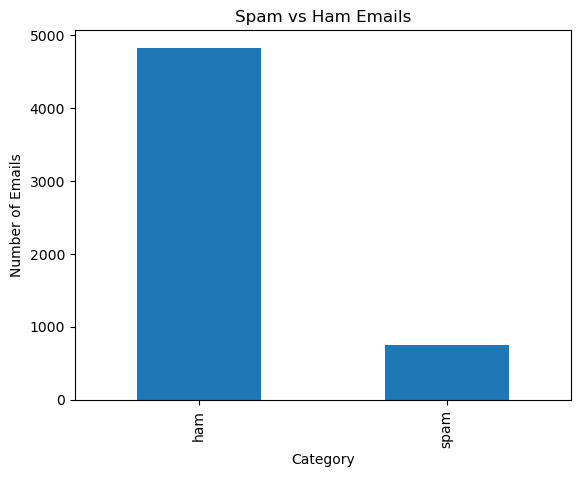

In [12]:
import matplotlib.pyplot as plt

data['Category'].value_counts().plot(kind='bar')

plt.title('Spam vs Ham Emails')
plt.xlabel('Category')
plt.ylabel('Number of Emails')
plt.show()

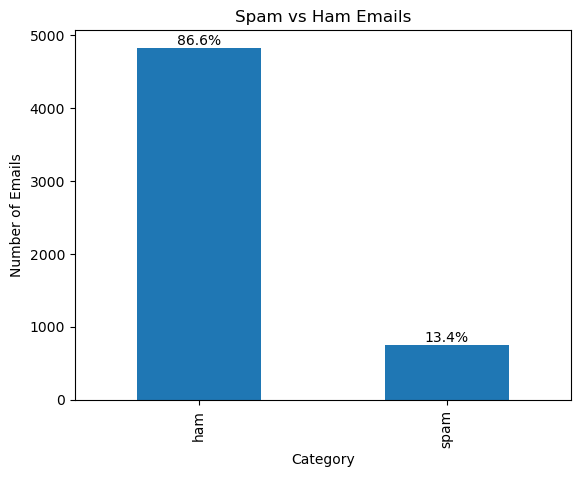

In [30]:
import matplotlib.pyplot as plt

ax = data['Category'].value_counts().plot(kind='bar')

plt.title('Spam vs Ham Emails')
plt.xlabel('Category')
plt.ylabel('Number of Emails')

# Add percentage on top of bars
total = len(data)
for bar in ax.patches:
    percentage = bar.get_height() / total * 100
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{percentage:.1f}%',
        ha='center',
        va='bottom'
    )

plt.show()

In [31]:
data['Message'].str.len().head(10)

0    102
1     23
2    149
3     43
4     59
5    138
6     75
7    154
8    150
9    152
Name: Message, dtype: int64

In [32]:
data['Message'] = data['Message'].str.lower()

In [33]:
data['Message'].head(5)

0    go until jurong point crazy available only in ...
1                              ok lar joking wif u oni
2    free entry in 2 a wkly comp to win fa cup fina...
3          u dun say so early hor u c already then say
4    nah i dont think he goes to usf he lives aroun...
Name: Message, dtype: object

In [34]:
import re
data['Message'] = data['Message'].apply(
    lambda x: re.sub(r'[^a-zA-Z0-9\s]', '', x)
)

In [35]:
data['Message'].head()

0    go until jurong point crazy available only in ...
1                              ok lar joking wif u oni
2    free entry in 2 a wkly comp to win fa cup fina...
3          u dun say so early hor u c already then say
4    nah i dont think he goes to usf he lives aroun...
Name: Message, dtype: object

In [36]:
data['Message'] = data['Message'].str.replace(r'\s+', ' ', regex=True).str.strip()

In [37]:
data['Message'].head()

0    go until jurong point crazy available only in ...
1                              ok lar joking wif u oni
2    free entry in 2 a wkly comp to win fa cup fina...
3          u dun say so early hor u c already then say
4    nah i dont think he goes to usf he lives aroun...
Name: Message, dtype: object

In [38]:
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(data['Message'])

In [39]:
X.toarray()[:5]

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(5, 9537))

In [40]:
vectorizer.get_feature_names_out()

array(['008704050406', '0089my', '0121', ..., 'zoom', 'zouk', 'zyada'],
      shape=(9537,), dtype=object)

In [41]:
feature_names = vectorizer.get_feature_names_out()

print(feature_names[:20])

['008704050406' '0089my' '0121' '01223585236' '01223585334' '0125698789'
 '02' '020603' '0207' '02070836089' '02072069400' '02073162414'
 '02085076972' '020903' '021' '050703' '0578' '06' '060505' '061104']


In [42]:
print(X.toarray()[:5, :20])

[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]]


In [43]:

y = data['Category']

y = y.map({'ham': 0, 'spam': 1})

In [44]:
print(y.head())

0    0
1    0
2    1
3    0
4    0
Name: Category, dtype: int64


In [45]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
random_state=42
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(4457, 9537)
(1115, 9537)
(4457,)
(1115,)


In [46]:
data['Message_Length'] = data['Message'].str.len()

# Boxplot Analysis

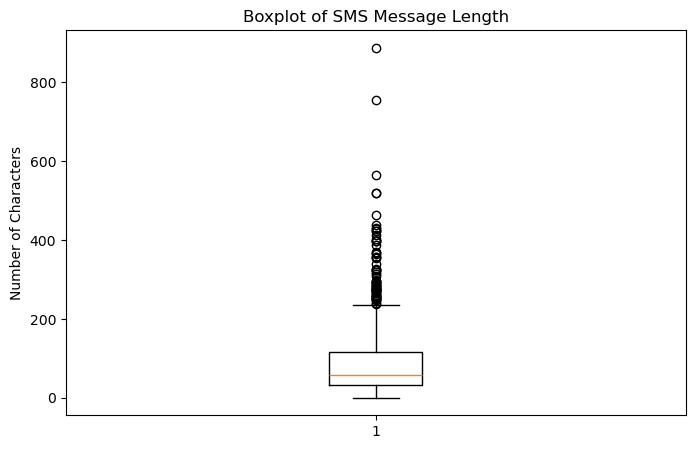

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.boxplot(data['Message_Length'])

plt.title('Boxplot of SMS Message Length')
plt.ylabel('Number of Characters')

plt.show()

In [48]:
data.head()

,Category,Message,Message_Length
0,ham,go until jurong point crazy available only in ...,102
1,ham,ok lar joking wif u oni,23
2,spam,free entry in 2 a wkly comp to win fa cup fina...,149
3,ham,u dun say so early hor u c already then say,43
4,ham,nah i dont think he goes to usf he lives aroun...,59


In [49]:
data['Category'] = data['Category'].map({
    'ham': 0,
    'spam': 1
})

In [50]:
data.head()

,Category,Message,Message_Length
0,0,go until jurong point crazy available only in ...,102
1,0,ok lar joking wif u oni,23
2,1,free entry in 2 a wkly comp to win fa cup fina...,149
3,0,u dun say so early hor u c already then say,43
4,0,nah i dont think he goes to usf he lives aroun...,59


# Message Length: Ham vs Spam

This comparison examines how message length varies between Ham and Spam messages.

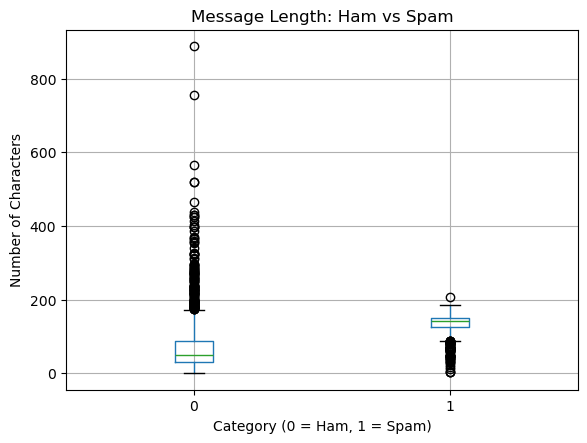

In [51]:
import matplotlib.pyplot as plt

data.boxplot(
    column='Message_Length',
    by='Category'
)

plt.title('Message Length: Ham vs Spam')
plt.suptitle('')
plt.xlabel('Category (0 = Ham, 1 = Spam)')
plt.ylabel('Number of Characters')

plt.show()

# Message Length Distribution: Ham vs Spam

A violin plot compares the distribution and density of message lengths between **Ham** and **Spam** messages.

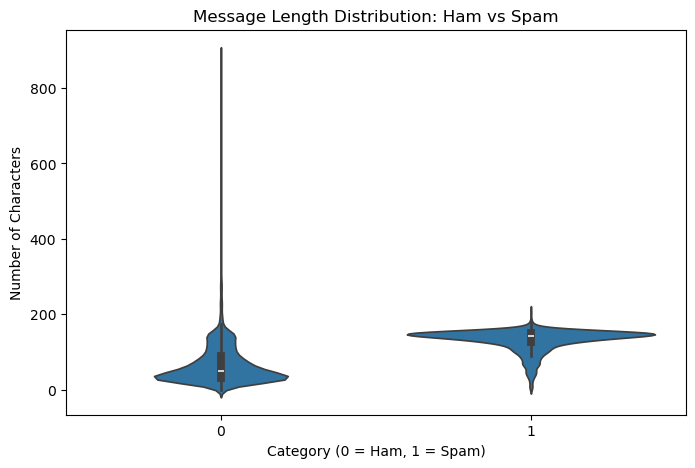

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.violinplot(
    data=data,
    x='Category',
    y='Message_Length'
) 

plt.title('Message Length Distribution: Ham vs Spam')
plt.xlabel('Category (0 = Ham, 1 = Spam)')
plt.ylabel('Number of Characters')

plt.show()

In [53]:
print("Duplicate rows:", data.duplicated().sum())

Duplicate rows: 443


# Duplicate Record Detection

Duplicate records are identified to prevent repeated messages from affecting model training and evaluation.

In [54]:
duplicates = data[data.duplicated(keep=False)]

print(duplicates.shape)
display(duplicates.head(20))

(747, 3)


,Category,Message,Message_Length
2,1,free entry in 2 a wkly comp to win fa cup fina...,149
7,0,as per your request melle melle oru minnaminun...,154
8,1,winner as a valued network customer you have b...,150
9,1,had your mobile 11 months or more u r entitled...,152
11,1,six chances to win cash from 100 to 20000 poun...,128
12,1,urgent you have won a 1 week free membership i...,146
45,0,no callsmessagesmissed calls,28
56,1,congrats 1 year special cinema pass for 2 is y...,148
57,0,sorry ill call later in meeting,31
62,0,its a part of checking iq,25


In [55]:
# checking duplicated values are indented 

print(
    data[data.duplicated(subset='Message', keep=False)]
    [['Category', 'Message']]
    .sort_values('Message')
    .head(20)
)

      Category                                            Message
3376         0                                                   
4824         0                                                   
1373         0  1 go to write msg 2 put on dictionary mode 3co...
2344         0  1 go to write msg 2 put on dictionary mode 3co...
2163         0  1 go to write msg 2 put on dictionary mode 3co...
2719         1  18 days to euro2004 kickoff u will be kept inf...
1050         1  18 days to euro2004 kickoff u will be kept inf...
389          1  4mths half price orange line rental latest cam...
2044         1  4mths half price orange line rental latest cam...
1470         0  7 wonders in my world 7th you 6th ur style 5th...
4556         0  7 wonders in my world 7th you 6th ur style 5th...
2982         0  7 wonders in my world 7th you 6th ur style 5th...
1779         0  7 wonders in my world 7th you 6th ur style 5th...
4652         1  a 400 xmas reward is waiting for you our compu...
5366      

# Droping Duplicated rows

In [56]:
# removing buplicated values 
print("Before:", data.shape)

data = data.drop_duplicates()

print("After:", data.shape)
print("Remaining duplicates:", data.duplicated().sum())

Before: (5572, 3)
After: (5129, 3)
Remaining duplicates: 0


In [57]:
# checking class balance 
print(data['Category'].value_counts())

Category
0    4499
1     630
Name: count, dtype: int64


In [58]:
print(data['Category'].value_counts(normalize=True) * 100)

Category
0    87.716904
1    12.283096
Name: proportion, dtype: float64


# Training and Testing Data — Logistic Regression

In [59]:
# seperating of x and y

X = data['Message']
y = data['Category']

In [60]:
# splitting the data 


from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [61]:
# checking the result 

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (4103,)
X_test : (1026,)
y_train: (4103,)
y_test : (1026,)


In [62]:
# class distribution 

print("Training:")
print(y_train.value_counts())

print("\nTesting:")
print(y_test.value_counts())

Training:
Category
0    3599
1     504
Name: count, dtype: int64

Testing:
Category
0    900
1    126
Name: count, dtype: int64


In [63]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words='english'
)

In [64]:
# Fit only on training data


X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [65]:
print("Training shape:", X_train_tfidf.shape)
print("Testing shape:", X_test_tfidf.shape)

Training shape: (4103, 8089)
Testing shape: (1026, 8089)


In [66]:
print("Training shape:", X_train_tfidf.shape)
print("Testing shape :", X_test_tfidf.shape)

Training shape: (4103, 8089)
Testing shape : (1026, 8089)


In [67]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train_tfidf, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [68]:
y_pred = model.predict(X_test_tfidf)

print("Predictions shape:", y_pred.shape)
print("First 20 predictions:", y_pred[:20])

Predictions shape: (1026,)
First 20 predictions: [0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0]


In [69]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

model.fit(X_train_tfidf, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


Confusion Matrix:
[[895   5]
 [ 43  83]]


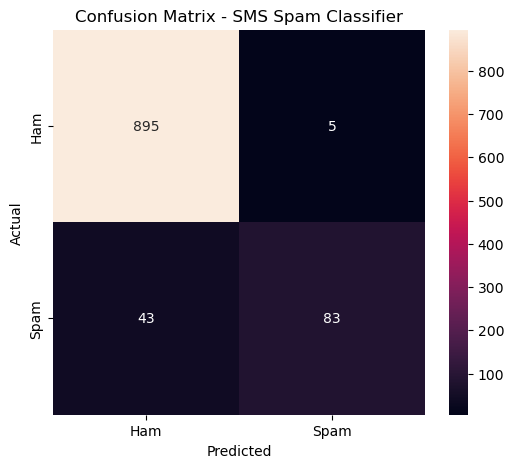

In [70]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Print numerical confusion matrix
print("Confusion Matrix:")
print(cm)

# Plot confusion matrix
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Ham', 'Spam'],
    yticklabels=['Ham', 'Spam']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - SMS Spam Classifier')

plt.show()

In [71]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.9532163742690059
Precision: 0.9431818181818182
Recall   : 0.6587301587301587
F1 Score : 0.7757009345794392


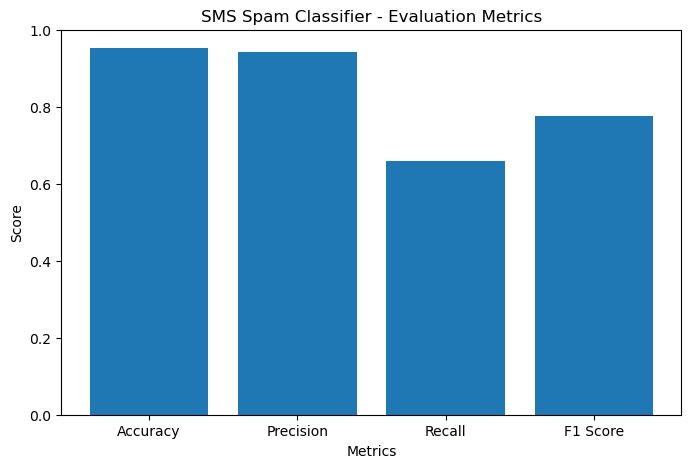

In [72]:
import matplotlib.pyplot as plt

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
scores = [accuracy, precision, recall, f1]

plt.figure(figsize=(8, 5))

plt.bar(metrics, scores)

plt.ylim(0, 1)

plt.xlabel('Metrics')
plt.ylabel('Score')
plt.title('SMS Spam Classifier - Evaluation Metrics')

plt.show()

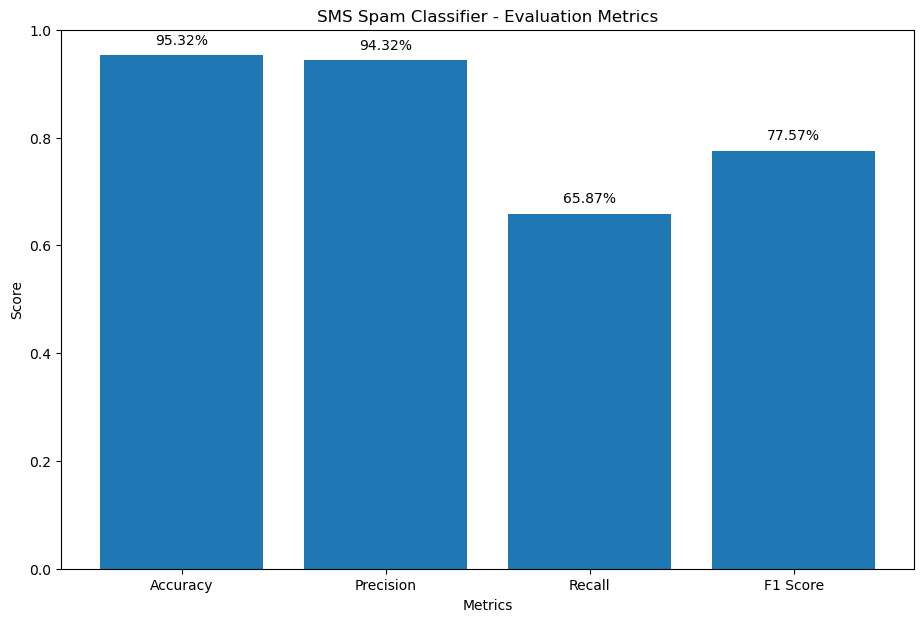

In [73]:
import matplotlib.pyplot as plt

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
scores = [accuracy, precision, recall, f1]

plt.figure(figsize=(11, 7))

bars = plt.bar(metrics, scores)

plt.ylim(0, 1)

plt.xlabel('Metrics')
plt.ylabel('Score')
plt.title('SMS Spam Classifier - Evaluation Metrics')

# Add percentage labels above each bar
for bar, score in zip(bars, scores):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        score + 0.02,
        f'{score * 100:.2f}%',
        ha='center'
    )

plt.show()

In [74]:
# inspecting what happening in confusion matrix 

print("Confusion Matrix:")
print(cm)

TN, FP, FN, TP = cm.ravel()

print("\nTN:", TN)
print("FP:", FP)
print("FN:", FN)
print("TP:", TP)

Confusion Matrix:
[[895   5]
 [ 43  83]]

TN: 895
FP: 5
FN: 43
TP: 83


Confusion Matrix:
[[895   5]
 [ 43  83]]

TN: 895
FP: 5
FN: 43
TP: 83


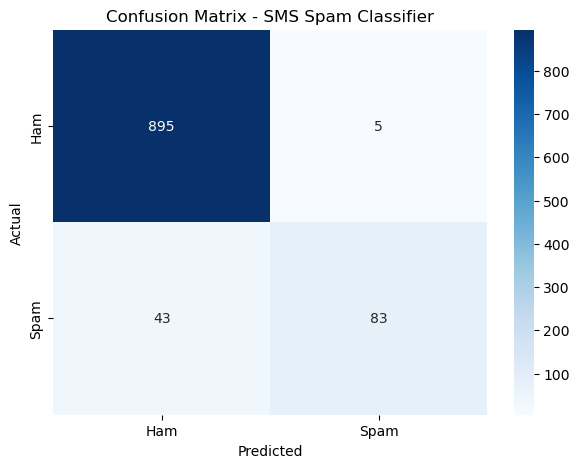

In [75]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Confusion Matrix:")
print(cm)

TN, FP, FN, TP = cm.ravel()

print("\nTN:", TN)
print("FP:", FP)
print("FN:", FN)
print("TP:", TP)


# Create confusion matrix diagram
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Ham', 'Spam'],
    yticklabels=['Ham', 'Spam']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - SMS Spam Classifier')

plt.show()

In [76]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=['Ham', 'Spam']
))

              precision    recall  f1-score   support

         Ham       0.95      0.99      0.97       900
        Spam       0.94      0.66      0.78       126

    accuracy                           0.95      1026
   macro avg       0.95      0.83      0.87      1026
weighted avg       0.95      0.95      0.95      1026



In [77]:
# spam probabilities 
# Get probability of each message being Spam
y_prob = model.predict_proba(X_test_tfidf)[:, 1]

print(y_prob[:20])

[0.29773429 0.22259235 0.83726551 0.73292993 0.17550761 0.09301585
 0.22975299 0.08309389 0.07165682 0.3033236  0.22792362 0.15860725
 0.05513565 0.90727285 0.25128561 0.06735622 0.09544979 0.08787912
 0.13786838 0.10440387]


In [86]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.50, 0.45, 0.40, 0.35, 0.30, 0.25]

for threshold in thresholds:

    y_pred_threshold = (y_prob >= threshold).astype(int)

    precision = precision_score(y_test, y_pred_threshold)
    recall = recall_score(y_test, y_pred_threshold)
    f1 = f1_score(y_test, y_pred_threshold)

    print(f"\nThreshold: {threshold}")
    print(f"Precision: {precision:.2f}")
    print(f"Recall   : {recall:.2f}")
    print(f"F1 Score : {f1:.2f}")


Threshold: 0.5
Precision: 0.87
Recall   : 0.90
F1 Score : 0.88

Threshold: 0.45
Precision: 0.85
Recall   : 0.91
F1 Score : 0.88

Threshold: 0.4
Precision: 0.80
Recall   : 0.91
F1 Score : 0.85

Threshold: 0.35
Precision: 0.73
Recall   : 0.92
F1 Score : 0.81

Threshold: 0.3
Precision: 0.64
Recall   : 0.94
F1 Score : 0.77

Threshold: 0.25
Precision: 0.54
Recall   : 0.98
F1 Score : 0.70


In [85]:
# calculate auc- roc curve
from sklearn.metrics import roc_auc_score

# Get the probability that each message is Spam
y_prob = model.predict_proba(X_test_tfidf)[:, 1]

# Calculate the ROC-AUC score
auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", auc)

ROC-AUC: 0.9809611992945325


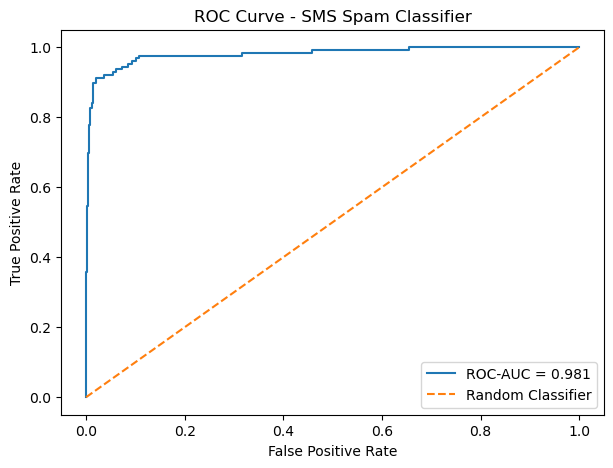

In [69]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# Calculate FPR, TPR and thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Plot ROC curve
plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f'ROC-AUC = {auc:.3f}'
)

# Random guessing line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Classifier'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - SMS Spam Classifier')
plt.legend()

plt.show()

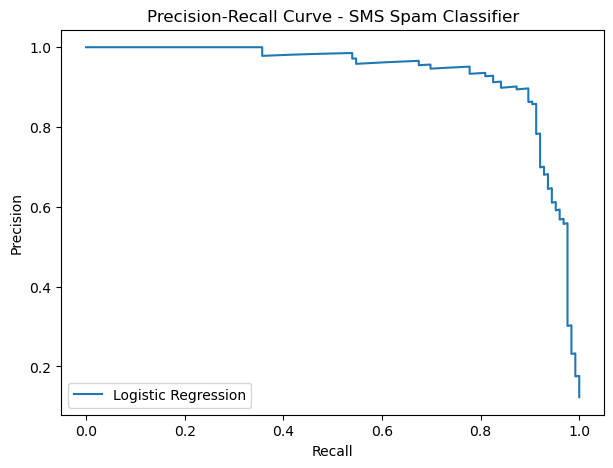

In [70]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

# Calculate precision, recall and thresholds
precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_prob
)

# Plot Precision-Recall curve
plt.figure(figsize=(7, 5))

plt.plot(
    recall,
    precision,
    label='Logistic Regression'
)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - SMS Spam Classifier')
plt.legend()

plt.show()

In [71]:
# Import precision_recall_curve from scikit-learn.
# It calculates Precision and Recall for different probability thresholds.
from sklearn.metrics import precision_recall_curve

# Import NumPy.
# We use NumPy here to find the position (index) of the highest F1 score.
import numpy as np


# ---------------------------------------------------------
# STEP 1: Calculate Precision, Recall and Thresholds
# ---------------------------------------------------------

# y_test = actual answers (0 = Ham, 1 = Spam)
#
# y_prob = probability predicted by Logistic Regression
#         for each SMS being Spam.
#
# precision_recall_curve() checks different thresholds
# and calculates Precision and Recall at each threshold.
precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_prob
)


# ---------------------------------------------------------
# STEP 2: Calculate F1 Score
# ---------------------------------------------------------

# F1 Score combines Precision and Recall into one score.
#
# Formula:
# F1 = 2 * (Precision * Recall) / (Precision + Recall)
#
# precision and recall have one extra value compared with
# thresholds, so we use [:-1] to make their lengths match
# with the thresholds array.
#
# 1e-10 is a very small number added to avoid division by zero.
f1_scores = (
    2 * precision[:-1] * recall[:-1]
    / (precision[:-1] + recall[:-1] + 1e-10)
)


# ---------------------------------------------------------
# STEP 3: Find the Best F1 Score
# ---------------------------------------------------------

# np.argmax() comes from NumPy.
# It returns the POSITION (index) of the largest value
# inside the f1_scores array.
best_index = np.argmax(f1_scores)


# ---------------------------------------------------------
# STEP 4: Get the Corresponding Threshold
# ---------------------------------------------------------

# Use the best index to find the probability threshold
# that produced the highest F1 score.
best_threshold = thresholds[best_index]


# ---------------------------------------------------------
# STEP 5: Get the Best F1 Score
# ---------------------------------------------------------

# Use the same index to get the highest F1 score.
best_f1 = f1_scores[best_index]


# ---------------------------------------------------------
# STEP 6: Display the Results
# ---------------------------------------------------------

print("Best Threshold:", best_threshold)
print("Best F1 Score  :", best_f1)

Best Threshold: 0.5445988051026301
Best F1 Score  : 0.8968253967753969


In [72]:
# ---------------------------------------------------------
# STEP 1: Create predictions using the new best threshold
# ---------------------------------------------------------

# y_prob contains the probability of each SMS being Spam.
#
# We compare every probability with our best threshold.
#
# If probability >= 0.5446 → predict Spam (1)
# If probability <  0.5446 → predict Ham  (0)
#
# The condition produces True/False values.
# astype(int) converts:
# True  → 1
# False → 0
y_pred_best = (y_prob >= best_threshold).astype(int)


# ---------------------------------------------------------
# STEP 2: Calculate the evaluation metrics
# ---------------------------------------------------------

# Import the metrics we want to evaluate.
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)


# Calculate overall accuracy.
accuracy_best = accuracy_score(y_test, y_pred_best)

# Calculate Spam precision.
precision_best = precision_score(y_test, y_pred_best)

# Calculate Spam recall.
recall_best = recall_score(y_test, y_pred_best)

# Calculate F1 score.
f1_best = f1_score(y_test, y_pred_best)


# ---------------------------------------------------------
# STEP 3: Display the results
# ---------------------------------------------------------

print("Results using Best Threshold")
print("--------------------------------")

print("Threshold :", best_threshold)
print("Accuracy  :", accuracy_best)
print("Precision :", precision_best)
print("Recall    :", recall_best)
print("F1 Score  :", f1_best)


# ---------------------------------------------------------
# STEP 4: Check the confusion matrix
# ---------------------------------------------------------

# This shows:
#
# TN = Ham correctly predicted as Ham
# FP = Ham incorrectly predicted as Spam
# FN = Spam incorrectly predicted as Ham
# TP = Spam correctly predicted as Spam
cm_best = confusion_matrix(y_test, y_pred_best)

print("\nConfusion Matrix:")
print(cm_best)

Results using Best Threshold
--------------------------------
Threshold : 0.5445988051026301
Accuracy  : 0.9746588693957114
Precision : 0.8968253968253969
Recall    : 0.8968253968253969
F1 Score  : 0.8968253968253969

Confusion Matrix:
[[887  13]
 [ 13 113]]


In [73]:
# ---------------------------------------------------------
# VERIFY THE ORIGINAL PREDICTIONS
# ---------------------------------------------------------

# Logistic Regression's predict() method uses its default
# classification threshold to convert probabilities into
# class labels.
y_pred_default = model.predict(X_test_tfidf)


# ---------------------------------------------------------
# CREATE PREDICTIONS USING PROBABILITY >= 0.50
# ---------------------------------------------------------

# Get the probability of Spam (class 1).
y_prob = model.predict_proba(X_test_tfidf)[:, 1]

# Convert probabilities into class predictions.
#
# Probability >= 0.50 → Spam (1)
# Probability <  0.50 → Ham  (0)
y_pred_050 = (y_prob >= 0.50).astype(int)


# ---------------------------------------------------------
# COMPARE BOTH PREDICTION METHODS
# ---------------------------------------------------------

print("Are model.predict() and 0.50 probability predictions identical?")

print(
    (y_pred_default == y_pred_050).all()
)


# ---------------------------------------------------------
# DISPLAY BOTH CONFUSION MATRICES
# ---------------------------------------------------------

print("\nConfusion Matrix using model.predict():")
print(confusion_matrix(y_test, y_pred_default))


print("\nConfusion Matrix using probability >= 0.50:")
print(confusion_matrix(y_test, y_pred_050))

Are model.predict() and 0.50 probability predictions identical?
True

Confusion Matrix using model.predict():
[[883  17]
 [ 13 113]]

Confusion Matrix using probability >= 0.50:
[[883  17]
 [ 13 113]]


In [74]:
# Import classification_report from scikit-learn.
# It gives us Precision, Recall, F1-score and Support
# for each class (Ham and Spam).
from sklearn.metrics import classification_report


# ---------------------------------------------------------
# Generate the classification report
# ---------------------------------------------------------

print("Classification Report - Best Threshold")
print("----------------------------------------")

print(
    classification_report(
        y_test,                 # Actual labels
        y_pred_best,            # Predictions using best threshold
        target_names=['Ham', 'Spam']
    )
)

Classification Report - Best Threshold
----------------------------------------
              precision    recall  f1-score   support

         Ham       0.99      0.99      0.99       900
        Spam       0.90      0.90      0.90       126

    accuracy                           0.97      1026
   macro avg       0.94      0.94      0.94      1026
weighted avg       0.97      0.97      0.97      1026



In [75]:
# ---------------------------------------------------------
# ERROR ANALYSIS
# ---------------------------------------------------------

# Create a copy of the test data.
# We do this so that we can inspect the messages
# without changing our original dataset.
error_analysis = data.loc[X_test.index].copy()


# Add the actual class from y_test.
# This tells us what the message really was.
error_analysis['Actual'] = y_test


# Add the prediction made by our model.
# This tells us what the model predicted.
error_analysis['Predicted'] = y_pred_best


# ---------------------------------------------------------
# Find False Positives
# ---------------------------------------------------------

# False Positive:
# Actual = 0 (Ham)
# Predicted = 1 (Spam)
false_positives = error_analysis[
    (error_analysis['Actual'] == 0) &
    (error_analysis['Predicted'] == 1)
]


# ---------------------------------------------------------
# Find False Negatives
# ---------------------------------------------------------

# False Negative:
# Actual = 1 (Spam)
# Predicted = 0 (Ham)
false_negatives = error_analysis[
    (error_analysis['Actual'] == 1) &
    (error_analysis['Predicted'] == 0)
]


# ---------------------------------------------------------
# Display the errors
# ---------------------------------------------------------

print("FALSE POSITIVES")
print("================")

print(
    false_positives[
        ['Message', 'Actual', 'Predicted']
    ].to_string(index=False)
)


print("\n\nFALSE NEGATIVES")
print("================")

print(
    false_negatives[
        ['Message', 'Actual', 'Predicted']
    ].to_string(index=False)
)

FALSE POSITIVES
                                                                                                                                           Message  Actual  Predicted
                                                                                                                    are you free nowcan i call now       0          1
                                                                                                                            i liked the new mobile       0          1
hi mobile no ltgt has added you in their contact list on wwwfullonsmscom it s a great place to send free sms to people for more visit fullonsmscom       0          1
                                                                                 text her if she doesnt reply let me know so i can have her log in       0          1
                                                                                                                       dont you have message offer       0

# Comparing Algorithems


# Naive Bias

              NAIVE BAYES - SMS SPAM CLASSIFIER

Predictions shape:
(1026,)

First 20 predictions:
[0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

Evaluation Metrics
----------------------------------------
Accuracy : 0.9591 (95.91%)
Precision: 1.0000 (100.00%)
Recall   : 0.6667 (66.67%)
F1 Score : 0.8000 (80.00%)
ROC-AUC  : 0.9736 (97.36%)

Confusion Matrix
----------------------------------------
[[900   0]
 [ 42  84]]

Confusion Matrix Values
----------------------------------------
TN: 900
FP: 0
FN: 42
TP: 84

Classification Report
----------------------------------------
              precision    recall  f1-score   support

         Ham       0.96      1.00      0.98       900
        Spam       1.00      0.67      0.80       126

    accuracy                           0.96      1026
   macro avg       0.98      0.83      0.89      1026
weighted avg       0.96      0.96      0.96      1026



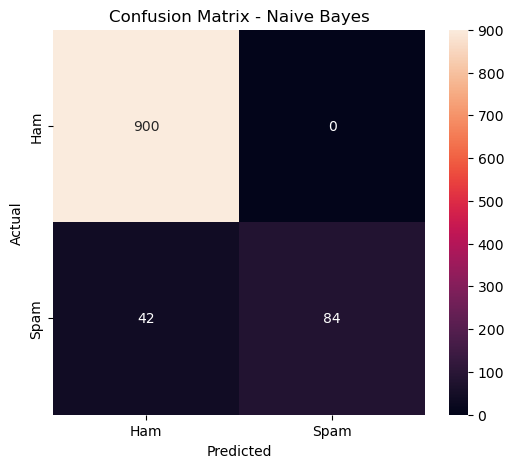

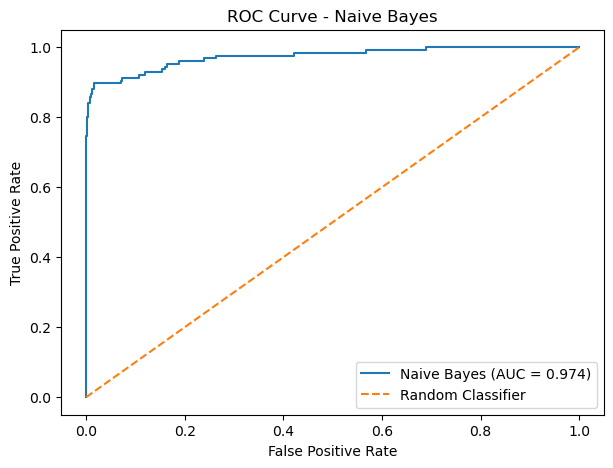

In [77]:
# ============================================================
# NAIVE BAYES - COMPLETE SMS SPAM CLASSIFIER
# ============================================================

# Import the Naive Bayes algorithm
from sklearn.naive_bayes import MultinomialNB

# Import evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

# Import matplotlib for plotting
import matplotlib.pyplot as plt

# Import seaborn for the confusion matrix visualization
import seaborn as sns


# ============================================================
# 1. CREATE THE NAIVE BAYES MODEL
# ============================================================

# MultinomialNB is commonly used for text classification
# because it works well with TF-IDF / word-count features.
#
# alpha=1.0 is the smoothing parameter.
# It helps prevent zero probabilities for unseen words.

nb_model = MultinomialNB(
    alpha=1.0
)


# ============================================================
# 2. TRAIN THE MODEL
# ============================================================

# X_train_tfidf = TF-IDF representation of training messages
# y_train        = actual labels (0 = Ham, 1 = Spam)

nb_model.fit(
    X_train_tfidf,
    y_train
)


# ============================================================
# 3. MAKE PREDICTIONS
# ============================================================

# Predict the final class:
# 0 = Ham
# 1 = Spam

y_pred_nb = nb_model.predict(
    X_test_tfidf
)


# ============================================================
# 4. CALCULATE BASIC CLASSIFICATION METRICS
# ============================================================

accuracy_nb = accuracy_score(
    y_test,
    y_pred_nb
)

precision_nb = precision_score(
    y_test,
    y_pred_nb
)

recall_nb = recall_score(
    y_test,
    y_pred_nb
)

f1_nb = f1_score(
    y_test,
    y_pred_nb
)


# ============================================================
# 5. CONFUSION MATRIX
# ============================================================

cm_nb = confusion_matrix(
    y_test,
    y_pred_nb
)

# Extract the four values
# TN = True Negative
# FP = False Positive
# FN = False Negative
# TP = True Positive

TN_nb, FP_nb, FN_nb, TP_nb = cm_nb.ravel()


# ============================================================
# 6. GET SPAM PROBABILITIES
# ============================================================

# Naive Bayes can give probabilities using predict_proba().
#
# predict_proba() returns:
#
# Column 0 -> probability of Ham
# Column 1 -> probability of Spam
#
# [:, 1] means:
# Take every row and only the Spam probability.

y_prob_nb = nb_model.predict_proba(
    X_test_tfidf
)[:, 1]


# ============================================================
# 7. ROC-AUC
# ============================================================

# ROC-AUC measures how well the model separates
# Spam from Ham across different probability thresholds.

auc_nb = roc_auc_score(
    y_test,
    y_prob_nb
)


# ============================================================
# 8. ROC CURVE
# ============================================================

# Calculate False Positive Rate (FPR)
# and True Positive Rate (TPR)

fpr_nb, tpr_nb, thresholds_nb = roc_curve(
    y_test,
    y_prob_nb
)


# ============================================================
# 9. PRINT COMPLETE RESULTS
# ============================================================

print("=" * 70)
print("              NAIVE BAYES - SMS SPAM CLASSIFIER")
print("=" * 70)

print("\nPredictions shape:")
print(y_pred_nb.shape)

print("\nFirst 20 predictions:")
print(y_pred_nb[:20])


print("\nEvaluation Metrics")
print("-" * 40)

print(
    f"Accuracy : {accuracy_nb:.4f} "
    f"({accuracy_nb * 100:.2f}%)"
)

print(
    f"Precision: {precision_nb:.4f} "
    f"({precision_nb * 100:.2f}%)"
)

print(
    f"Recall   : {recall_nb:.4f} "
    f"({recall_nb * 100:.2f}%)"
)

print(
    f"F1 Score : {f1_nb:.4f} "
    f"({f1_nb * 100:.2f}%)"
)

print(
    f"ROC-AUC  : {auc_nb:.4f} "
    f"({auc_nb * 100:.2f}%)"
)


print("\nConfusion Matrix")
print("-" * 40)

print(cm_nb)


print("\nConfusion Matrix Values")
print("-" * 40)

print("TN:", TN_nb)
print("FP:", FP_nb)
print("FN:", FN_nb)
print("TP:", TP_nb)


print("\nClassification Report")
print("-" * 40)

print(
    classification_report(
        y_test,
        y_pred_nb,
        target_names=['Ham', 'Spam']
    )
)


# ============================================================
# 10. PLOT CONFUSION MATRIX
# ============================================================

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_nb,
    annot=True,
    fmt='d',
    xticklabels=['Ham', 'Spam'],
    yticklabels=['Ham', 'Spam']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Naive Bayes')

plt.show()


# ============================================================
# 11. PLOT ROC CURVE
# ============================================================

plt.figure(figsize=(7, 5))

plt.plot(
    fpr_nb,
    tpr_nb,
    label=f'Naive Bayes (AUC = {auc_nb:.3f})'
)

# Random classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Classifier'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('ROC Curve - Naive Bayes')

plt.legend()

plt.show()

# SVM( Support Vector Machine)

LINEAR SVM - SMS SPAM CLASSIFIER

Predictions shape:
(1026,)

First 20 predictions:
[0 0 1 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0]

Evaluation Metrics
------------------------------
Accuracy : 0.9766 (97.66%)
Precision: 0.9180 (91.80%)
Recall   : 0.8889 (88.89%)
F1 Score : 0.9032 (90.32%)
ROC-AUC  : 0.9846 (98.46%)

Confusion Matrix
------------------------------
[[890  10]
 [ 14 112]]

TN: 890
FP: 10
FN: 14
TP: 112

Classification Report
------------------------------
              precision    recall  f1-score   support

         Ham       0.98      0.99      0.99       900
        Spam       0.92      0.89      0.90       126

    accuracy                           0.98      1026
   macro avg       0.95      0.94      0.94      1026
weighted avg       0.98      0.98      0.98      1026



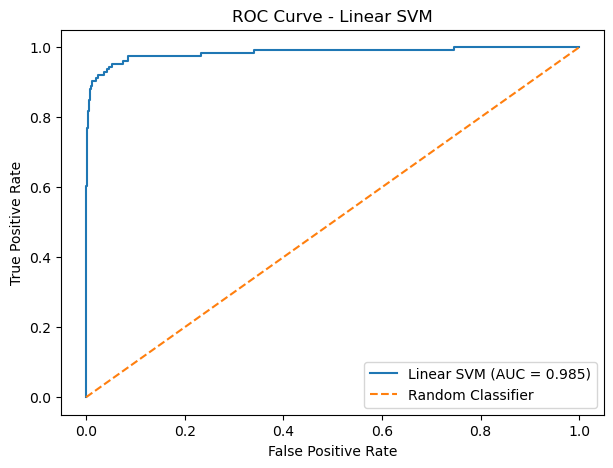

In [78]:
# ============================================================
# LINEAR SVM - SMS SPAM CLASSIFICATION
# ============================================================

# ------------------------------------------------------------
# 1. Import LinearSVC
# ------------------------------------------------------------
# LinearSVC comes from scikit-learn.
#
# SVC = Support Vector Classifier
#
# LinearSVC is a Support Vector Machine designed to find
# a linear decision boundary between classes.
#
# It works very well with high-dimensional text data
# such as TF-IDF features.
from sklearn.svm import LinearSVC


# ------------------------------------------------------------
# 2. Import evaluation metrics
# ------------------------------------------------------------
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

import matplotlib.pyplot as plt


# ============================================================
# 3. Create the Linear SVM model
# ============================================================

# C controls the strength of regularization.
#
# Smaller C:
#     Stronger regularization
#     Simpler decision boundary
#
# Larger C:
#     Weaker regularization
#     Model tries harder to classify training examples
#
# C=1.0 is a good starting point.
#
# class_weight='balanced':
#     Gives more importance to the minority Spam class.
#
# random_state=42:
#     Helps make results reproducible.
svm_model = LinearSVC(
    C=1.0,
    class_weight='balanced',
    random_state=42
)


# ============================================================
# 4. Train the Linear SVM model
# ============================================================

# X_train_tfidf:
#     TF-IDF representation of training SMS.
#
# y_train:
#     Labels:
#     0 = Ham
#     1 = Spam
#
# The SVM learns a boundary that separates
# Ham and Spam messages.
svm_model.fit(
    X_train_tfidf,
    y_train
)


# ============================================================
# 5. Make predictions
# ============================================================

# Predict the classes of the test SMS.
#
# Output:
#     0 = Ham
#     1 = Spam
y_pred_svm = svm_model.predict(
    X_test_tfidf
)


# ============================================================
# 6. Calculate evaluation metrics
# ============================================================

# Accuracy:
# How many total predictions were correct?
accuracy_svm = accuracy_score(
    y_test,
    y_pred_svm
)


# Precision:
# Of the messages predicted as Spam,
# how many were actually Spam?
precision_svm = precision_score(
    y_test,
    y_pred_svm
)


# Recall:
# Of all actual Spam messages,
# how many did the model detect?
recall_svm = recall_score(
    y_test,
    y_pred_svm
)


# F1 Score:
# Balance between Precision and Recall.
f1_svm = f1_score(
    y_test,
    y_pred_svm
)


# ============================================================
# 7. Confusion Matrix
# ============================================================

cm_svm = confusion_matrix(
    y_test,
    y_pred_svm
)


# Extract:
# TN = True Negative
# FP = False Positive
# FN = False Negative
# TP = True Positive
TN_svm, FP_svm, FN_svm, TP_svm = cm_svm.ravel()


# ============================================================
# 8. ROC-AUC
# ============================================================

# IMPORTANT:
#
# LinearSVC does NOT have predict_proba().
#
# Instead, decision_function() gives a score showing
# how strongly a message belongs to one class or the other.
#
# Higher score → more likely Spam
# Lower score  → more likely Ham
y_score_svm = svm_model.decision_function(
    X_test_tfidf
)


# Calculate ROC-AUC using the decision scores.
auc_svm = roc_auc_score(
    y_test,
    y_score_svm
)


# ============================================================
# 9. Print model results
# ============================================================

print("=" * 60)
print("LINEAR SVM - SMS SPAM CLASSIFIER")
print("=" * 60)


print("\nPredictions shape:")
print(y_pred_svm.shape)


print("\nFirst 20 predictions:")
print(y_pred_svm[:20])


# ------------------------------------------------------------
# Evaluation Metrics
# ------------------------------------------------------------

print("\nEvaluation Metrics")
print("-" * 30)

print(
    f"Accuracy : {accuracy_svm:.4f} "
    f"({accuracy_svm * 100:.2f}%)"
)

print(
    f"Precision: {precision_svm:.4f} "
    f"({precision_svm * 100:.2f}%)"
)

print(
    f"Recall   : {recall_svm:.4f} "
    f"({recall_svm * 100:.2f}%)"
)

print(
    f"F1 Score : {f1_svm:.4f} "
    f"({f1_svm * 100:.2f}%)"
)

print(
    f"ROC-AUC  : {auc_svm:.4f} "
    f"({auc_svm * 100:.2f}%)"
)


# ------------------------------------------------------------
# Confusion Matrix
# ------------------------------------------------------------

print("\nConfusion Matrix")
print("-" * 30)

print(cm_svm)


print("\nTN:", TN_svm)
print("FP:", FP_svm)
print("FN:", FN_svm)
print("TP:", TP_svm)


# ------------------------------------------------------------
# Classification Report
# ------------------------------------------------------------

print("\nClassification Report")
print("-" * 30)

print(
    classification_report(
        y_test,
        y_pred_svm,
        target_names=['Ham', 'Spam']
    )
)


# ============================================================
# 10. ROC Curve
# ============================================================

# Calculate False Positive Rate and True Positive Rate.
fpr_svm, tpr_svm, thresholds_svm = roc_curve(
    y_test,
    y_score_svm
)


# Create ROC curve.
plt.figure(figsize=(7, 5))

plt.plot(
    fpr_svm,
    tpr_svm,
    label=f'Linear SVM (AUC = {auc_svm:.3f})'
)


# Random classifier reference line.
plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Classifier'
)


plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('ROC Curve - Linear SVM')

plt.legend()

plt.show()

DECISION TREE - SMS SPAM CLASSIFIER

Predictions shape:
(1026,)

First 20 predictions:
[0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

Evaluation Metrics
------------------------------
Accuracy : 0.9474 (94.74%)
Precision: 0.8051 (80.51%)
Recall   : 0.7540 (75.40%)
F1 Score : 0.7787 (77.87%)
ROC-AUC  : 0.8279 (82.79%)

Confusion Matrix
------------------------------
[[877  23]
 [ 31  95]]

TN: 877
FP: 23
FN: 31
TP: 95

Classification Report
------------------------------
              precision    recall  f1-score   support

         Ham       0.97      0.97      0.97       900
        Spam       0.81      0.75      0.78       126

    accuracy                           0.95      1026
   macro avg       0.89      0.86      0.87      1026
weighted avg       0.95      0.95      0.95      1026



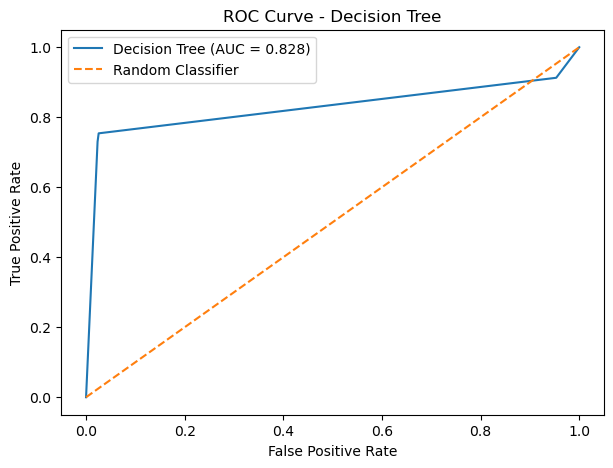

In [79]:
# ============================================================
# DECISION TREE - SMS SPAM CLASSIFICATION
# ============================================================

# ------------------------------------------------------------
# 1. Import Decision Tree
# ------------------------------------------------------------
# DecisionTreeClassifier is a supervised ML algorithm
# used for classification problems.
#
# It learns a series of questions/rules such as:
#
#        Is word "free" important?
#              /        \
#            Yes         No
#            /            \
#         Spam            Ham
#
# For our project, the input is TF-IDF numerical features.
from sklearn.tree import DecisionTreeClassifier


# ------------------------------------------------------------
# 2. Import evaluation metrics
# ------------------------------------------------------------
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

import matplotlib.pyplot as plt


# ============================================================
# 3. Create the Decision Tree model
# ============================================================

# max_depth:
# Controls how deep the tree can grow.
#
# If the tree is allowed to grow without restriction,
# it can become very complicated and overfit the training data.
#
# max_depth=20 gives the tree enough flexibility while
# limiting excessive growth.
#
# class_weight='balanced':
# Gives more importance to the minority Spam class.
#
# random_state=42:
# Makes the result reproducible.
dt_model = DecisionTreeClassifier(
    max_depth=20,
    class_weight='balanced',
    random_state=42
)


# ============================================================
# 4. Train the Decision Tree
# ============================================================

# X_train_tfidf:
#     Training SMS converted into TF-IDF numerical features.
#
# y_train:
#     Training labels:
#     0 = Ham
#     1 = Spam
#
# The Decision Tree learns patterns that separate
# Ham and Spam.
dt_model.fit(
    X_train_tfidf,
    y_train
)


# ============================================================
# 5. Make predictions
# ============================================================

# Predict the class of every SMS in the test set.
#
# 0 = Ham
# 1 = Spam
y_pred_dt = dt_model.predict(
    X_test_tfidf
)


# ============================================================
# 6. Calculate evaluation metrics
# ============================================================

# Accuracy:
# Percentage of all test messages classified correctly.
accuracy_dt = accuracy_score(
    y_test,
    y_pred_dt
)


# Precision:
# Of the messages predicted as Spam,
# how many were actually Spam?
precision_dt = precision_score(
    y_test,
    y_pred_dt
)


# Recall:
# Of all actual Spam messages,
# how many did the model successfully detect?
recall_dt = recall_score(
    y_test,
    y_pred_dt
)


# F1 Score:
# Harmonic mean of Precision and Recall.
f1_dt = f1_score(
    y_test,
    y_pred_dt
)


# ============================================================
# 7. Confusion Matrix
# ============================================================

cm_dt = confusion_matrix(
    y_test,
    y_pred_dt
)


# Extract the four values:
#
# TN = True Negative
# FP = False Positive
# FN = False Negative
# TP = True Positive
TN_dt, FP_dt, FN_dt, TP_dt = cm_dt.ravel()


# ============================================================
# 8. ROC-AUC
# ============================================================

# Decision Tree DOES have predict_proba().
#
# [:, 1] means:
#     Take the probability of class 1 = Spam.
#
# Example:
# [0.95, 0.05] → 5% Spam
# [0.20, 0.80] → 80% Spam
y_prob_dt = dt_model.predict_proba(
    X_test_tfidf
)[:, 1]


# Calculate ROC-AUC.
auc_dt = roc_auc_score(
    y_test,
    y_prob_dt
)


# ============================================================
# 9. Print results
# ============================================================

print("=" * 60)
print("DECISION TREE - SMS SPAM CLASSIFIER")
print("=" * 60)


print("\nPredictions shape:")
print(y_pred_dt.shape)


print("\nFirst 20 predictions:")
print(y_pred_dt[:20])


# ------------------------------------------------------------
# Evaluation Metrics
# ------------------------------------------------------------

print("\nEvaluation Metrics")
print("-" * 30)

print(
    f"Accuracy : {accuracy_dt:.4f} "
    f"({accuracy_dt * 100:.2f}%)"
)

print(
    f"Precision: {precision_dt:.4f} "
    f"({precision_dt * 100:.2f}%)"
)

print(
    f"Recall   : {recall_dt:.4f} "
    f"({recall_dt * 100:.2f}%)"
)

print(
    f"F1 Score : {f1_dt:.4f} "
    f"({f1_dt * 100:.2f}%)"
)

print(
    f"ROC-AUC  : {auc_dt:.4f} "
    f"({auc_dt * 100:.2f}%)"
)


# ------------------------------------------------------------
# Confusion Matrix
# ------------------------------------------------------------

print("\nConfusion Matrix")
print("-" * 30)

print(cm_dt)


print("\nTN:", TN_dt)
print("FP:", FP_dt)
print("FN:", FN_dt)
print("TP:", TP_dt)


# ------------------------------------------------------------
# Classification Report
# ------------------------------------------------------------

print("\nClassification Report")
print("-" * 30)

print(
    classification_report(
        y_test,
        y_pred_dt,
        target_names=['Ham', 'Spam']
    )
)


# ============================================================
# 10. ROC Curve
# ============================================================

# Calculate False Positive Rate and True Positive Rate.
fpr_dt, tpr_dt, thresholds_dt = roc_curve(
    y_test,
    y_prob_dt
)


# Create ROC curve.
plt.figure(figsize=(7, 5))

plt.plot(
    fpr_dt,
    tpr_dt,
    label=f'Decision Tree (AUC = {auc_dt:.3f})'
)


# Random classifier reference line.
plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Classifier'
)


plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('ROC Curve - Decision Tree')

plt.legend()

plt.show()

In [80]:
import pandas as pd

# ============================================================
# FINAL MODEL COMPARISON
# ============================================================

comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Naive Bayes',
        'Linear SVM',
        'Decision Tree'
    ],

    'Accuracy': [
        accuracy_best,
        accuracy_nb,
        accuracy_svm,
        accuracy_dt
    ],

    'Precision': [
        precision_best,
        precision_nb,
        precision_svm,
        precision_dt
    ],

    'Recall': [
        recall_best,
        recall_nb,
        recall_svm,
        recall_dt
    ],

    'F1 Score': [
        f1_best,
        f1_nb,
        f1_svm,
        f1_dt
    ],

    # IMPORTANT:
    # Naive Bayes must use auc_nb, NOT None
    'ROC-AUC': [
        auc,
        auc_nb,
        auc_svm,
        auc_dt
    ]
})


# Convert decimal values to percentages
for column in [
    'Accuracy',
    'Precision',
    'Recall',
    'F1 Score',
    'ROC-AUC'
]:
    
    comparison[column] = comparison[column].apply(
        lambda x: f'{x * 100:.2f}%'
    )


print("=" * 90)
print("              ML MODEL COMPARISON - SMS SPAM CLASSIFIER")
print("=" * 90)

print(comparison.to_string(index=False))

              ML MODEL COMPARISON - SMS SPAM CLASSIFIER
              Model Accuracy Precision Recall F1 Score ROC-AUC
Logistic Regression   97.47%    89.68% 89.68%   89.68%  98.10%
        Naive Bayes   95.91%   100.00% 66.67%   80.00%  97.36%
         Linear SVM   97.66%    91.80% 88.89%   90.32%  98.46%
      Decision Tree   94.74%    80.51% 75.40%   77.87%  82.79%


# saving the mode


In [81]:
# ============================================================
# SAVE FINAL MODEL AND TF-IDF VECTORIZER
# ============================================================

import joblib

# svm_model = our final trained Linear SVM
# tfidf = the TF-IDF vectorizer that was fitted on X_train

joblib.dump(
    svm_model,
    'sms_spam_svm_model.pkl'
)

joblib.dump(
    tfidf,
    'sms_spam_tfidf.pkl'
)

print("Final model saved successfully!")
print("Model     : sms_spam_svm_model.pkl")
print("Vectorizer: sms_spam_tfidf.pkl")

Final model saved successfully!
Model     : sms_spam_svm_model.pkl
Vectorizer: sms_spam_tfidf.pkl


# loding and saving Files

In [82]:
import joblib

loaded_tfidf = joblib.load('sms_spam_tfidf.pkl')
loaded_svm = joblib.load('sms_spam_svm_model.pkl')

print("TF-IDF loaded successfully!")
print("SVM model loaded successfully!")

TF-IDF loaded successfully!
SVM model loaded successfully!


# Testing new sms messages

In [83]:
# ============================================================
# TEST THE SAVED SMS SPAM CLASSIFIER ON NEW MESSAGES
# ============================================================

# These are completely new messages.
# The model has not seen these messages during training.
new_messages = [
    "Congratulations! You won a free prize. Call now!",
    "Hey buddy, are you coming to college today?",
    "URGENT! You have won a cash prize. Reply now!",
    "Can you call me when you are free?"
]

# ------------------------------------------------------------
# STEP 1: Convert the new text into TF-IDF numbers
# ------------------------------------------------------------
# IMPORTANT:
# We use transform(), NOT fit_transform().
#
# Why?
# Because our saved TF-IDF vectorizer already learned the
# vocabulary from the training data.
new_messages_tfidf = loaded_tfidf.transform(new_messages)

print("TF-IDF shape:")
print(new_messages_tfidf.shape)


# ------------------------------------------------------------
# STEP 2: Give the TF-IDF numbers to the saved SVM model
# ------------------------------------------------------------
new_predictions = loaded_svm.predict(new_messages_tfidf)


# ------------------------------------------------------------
# STEP 3: Display the predictions
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("NEW SMS PREDICTIONS")
print("=" * 60)

for message, prediction in zip(new_messages, new_predictions):

    # Our encoding:
    # 0 = Ham
    # 1 = Spam
    if prediction == 1:
        result = "SPAM"
    else:
        result = "HAM"

    print("\nMessage:", message)
    print("Prediction:", result)

TF-IDF shape:
(4, 8089)

NEW SMS PREDICTIONS

Message: Congratulations! You won a free prize. Call now!
Prediction: SPAM

Message: Hey buddy, are you coming to college today?
Prediction: HAM

Message: URGENT! You have won a cash prize. Reply now!
Prediction: SPAM

Message: Can you call me when you are free?
Prediction: SPAM


# manual testing

In [ ]:
message = input("Enter an SMS: ")

message_tfidf = loaded_tfidf.transform([message])

prediction = loaded_svm.predict(message_tfidf)[0]

if prediction == 1:
    print("Prediction: SPAM")
else:
    print("Prediction: HAM")

In [84]:
messages = [
    "Congratulations! You won a free prize. Call now!",
    "Hey buddy, are you coming to college today?",
    "URGENT! You have won a cash prize. Reply now!",
    "Can you call me when you are free?"
]

X_new = loaded_tfidf.transform(messages)

predictions = loaded_svm.predict(X_new)

print("=" * 60)
print("SAVED SVM MODEL - NEW SMS PREDICTIONS")
print("=" * 60)

for message, prediction in zip(messages, predictions):
    print("\nMessage:", message)
    print("Prediction:", prediction)

SAVED SVM MODEL - NEW SMS PREDICTIONS

Message: Congratulations! You won a free prize. Call now!
Prediction: 1

Message: Hey buddy, are you coming to college today?
Prediction: 0

Message: URGENT! You have won a cash prize. Reply now!
Prediction: 1

Message: Can you call me when you are free?
Prediction: 1


In [85]:
message = ["Can you call me when you are free?"]

X = loaded_tfidf.transform(message)

prediction = loaded_svm.predict(X)
decision = loaded_svm.decision_function(X)

print("Prediction:", prediction[0])
print("Decision score:", decision[0])

Prediction: 1
Decision score: 0.4136302331108541


In [86]:
feature_names = loaded_tfidf.get_feature_names_out()
coefficients = loaded_svm.coef_[0]

message_vector = X.toarray()[0]

word_scores = message_vector * coefficients

important_words = []

for i in range(len(feature_names)):
    if message_vector[i] != 0:
        important_words.append(
            (
                feature_names[i],
                message_vector[i],
                coefficients[i],
                word_scores[i]
            )
        )

important_words = sorted(
    important_words,
    key=lambda x: abs(x[3]),
    reverse=True
)

print("=" * 80)
print("FEATURE CONTRIBUTIONS")
print("=" * 80)

for word, tfidf_value, coefficient, contribution in important_words:
    print(
        f"{word:20} "
        f"TF-IDF={tfidf_value:.4f}  "
        f"Coefficient={coefficient:.4f}  "
        f"Contribution={contribution:.4f}"
    )

FEATURE CONTRIBUTIONS
free                 TF-IDF=1.0000  Coefficient=1.1552  Contribution=1.1552


In [87]:
print(loaded_tfidf.get_params())

{'analyzer': 'word', 'binary': False, 'decode_error': 'strict', 'dtype': <class 'numpy.float64'>, 'encoding': 'utf-8', 'input': 'content', 'lowercase': True, 'max_df': 1.0, 'max_features': None, 'min_df': 1, 'ngram_range': (1, 1), 'norm': 'l2', 'preprocessor': None, 'smooth_idf': True, 'stop_words': 'english', 'strip_accents': None, 'sublinear_tf': False, 'token_pattern': '(?u)\\b\\w\\w+\\b', 'tokenizer': None, 'use_idf': True, 'vocabulary': None}


In [88]:
print("call in vocabulary:", "call" in loaded_tfidf.vocabulary_)
print("free in vocabulary:", "free" in loaded_tfidf.vocabulary_)

print("\nNumber of features:", len(loaded_tfidf.get_feature_names_out()))

print("\nSVM classes:", loaded_svm.classes_)
print("SVM intercept:", loaded_svm.intercept_[0])

call in vocabulary: False
free in vocabulary: True

Number of features: 8089

SVM classes: [0 1]
SVM intercept: -0.7415496949720402


In [89]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

# New TF-IDF
tfidf_bi = TfidfVectorizer(
    lowercase=True,
    stop_words=None,
    ngram_range=(1, 2)
)

# Fit ONLY on training data
X_train_tfidf_bi = tfidf_bi.fit_transform(X_train)

# Transform test data
X_test_tfidf_bi = tfidf_bi.transform(X_test)

print("Training shape:", X_train_tfidf_bi.shape)
print("Testing shape :", X_test_tfidf_bi.shape)

# New SVM
svm_bi = LinearSVC(
    C=1.0,
    class_weight='balanced',
    random_state=42
)

svm_bi.fit(
    X_train_tfidf_bi,
    y_train
)

# Test predictions
y_pred_bi = svm_bi.predict(X_test_tfidf_bi)

print("\nNew TF-IDF + SVM model created successfully!")

Training shape: (4103, 43128)
Testing shape : (1026, 43128)

New TF-IDF + SVM model created successfully!


In [90]:
# Test the problematic message with the NEW TF-IDF + SVM model

test_message = ["Can you call me when you are free?"]

X_message = tfidf_bi.transform(test_message)

prediction = svm_bi.predict(X_message)
decision = svm_bi.decision_function(X_message)

print("=" * 60)
print("NEW MODEL TEST")
print("=" * 60)

print("\nMessage:")
print(test_message[0])

print("\nPrediction:")
print(prediction[0])

print("\nDecision Score:")
print(decision[0])

if prediction[0] == 0:
    print("\nResult: HAM")
else:
    print("\nResult: SPAM")

NEW MODEL TEST

Message:
Can you call me when you are free?

Prediction:
0

Decision Score:
-0.7837117024132912

Result: HAM


In [91]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score
)

# ============================================================
# NEW TF-IDF + SVM EVALUATION
# ============================================================

accuracy_bi = accuracy_score(y_test, y_pred_bi)
precision_bi = precision_score(y_test, y_pred_bi)
recall_bi = recall_score(y_test, y_pred_bi)
f1_bi = f1_score(y_test, y_pred_bi)

cm_bi = confusion_matrix(y_test, y_pred_bi)

TN_bi, FP_bi, FN_bi, TP_bi = cm_bi.ravel()

y_score_bi = svm_bi.decision_function(X_test_tfidf_bi)

auc_bi = roc_auc_score(
    y_test,
    y_score_bi
)

print("=" * 60)
print("NEW TF-IDF + LINEAR SVM")
print("=" * 60)

print("\nEvaluation Metrics")
print("-" * 30)

print(f"Accuracy : {accuracy_bi:.4f} ({accuracy_bi * 100:.2f}%)")
print(f"Precision: {precision_bi:.4f} ({precision_bi * 100:.2f}%)")
print(f"Recall   : {recall_bi:.4f} ({recall_bi * 100:.2f}%)")
print(f"F1 Score : {f1_bi:.4f} ({f1_bi * 100:.2f}%)")
print(f"ROC-AUC  : {auc_bi:.4f} ({auc_bi * 100:.2f}%)")

print("\nConfusion Matrix")
print("-" * 30)

print(cm_bi)

print("\nTN:", TN_bi)
print("FP:", FP_bi)
print("FN:", FN_bi)
print("TP:", TP_bi)

NEW TF-IDF + LINEAR SVM

Evaluation Metrics
------------------------------
Accuracy : 0.9786 (97.86%)
Precision: 0.9262 (92.62%)
Recall   : 0.8968 (89.68%)
F1 Score : 0.9113 (91.13%)
ROC-AUC  : 0.9817 (98.17%)

Confusion Matrix
------------------------------
[[891   9]
 [ 13 113]]

TN: 891
FP: 9
FN: 13
TP: 113


In [92]:
test_messages = [
    "Can you call me when you are free?",
    "Congratulations! You won a free prize. Call now!",
    "Hey buddy, are you coming to college today?",
    "URGENT! You have won a cash prize. Reply now!",
    "Your appointment is confirmed for tomorrow.",
    "FREE entry in a weekly competition. Text WIN now!",
    "Can you send me the notes from today's class?",
    "You have won $1000. Claim your prize now!"
]

X_test_messages = tfidf_bi.transform(test_messages)

predictions = svm_bi.predict(X_test_messages)

print("=" * 60)
print("NEW MODEL - SMS PREDICTIONS")
print("=" * 60)

for message, prediction in zip(test_messages, predictions):
    label = "SPAM" if prediction == 1 else "HAM"
    
    print("\nMessage:", message)
    print("Prediction:", label)

NEW MODEL - SMS PREDICTIONS

Message: Can you call me when you are free?
Prediction: HAM

Message: Congratulations! You won a free prize. Call now!
Prediction: SPAM

Message: Hey buddy, are you coming to college today?
Prediction: HAM

Message: URGENT! You have won a cash prize. Reply now!
Prediction: SPAM

Message: Your appointment is confirmed for tomorrow.
Prediction: HAM

Message: FREE entry in a weekly competition. Text WIN now!
Prediction: SPAM

Message: Can you send me the notes from today's class?
Prediction: HAM

Message: You have won $1000. Claim your prize now!
Prediction: SPAM


In [93]:
import joblib

# Save the improved TF-IDF vectorizer
joblib.dump(
    tfidf_bi,
    'sms_spam_tfidf_bigrams.pkl'
)

# Save the improved SVM model
joblib.dump(
    svm_bi,
    'sms_spam_svm_bigrams.pkl'
)

print("Improved TF-IDF saved successfully!")
print("Improved SVM model saved successfully!")

Improved TF-IDF saved successfully!
Improved SVM model saved successfully!


In [94]:
import joblib

# Load the saved improved model
final_tfidf = joblib.load(
    'sms_spam_tfidf_bigrams.pkl'
)

final_svm = joblib.load(
    'sms_spam_svm_bigrams.pkl'
)

print("Saved TF-IDF loaded successfully!")
print("Saved SVM loaded successfully!")

# Test a new SMS
message = "Can you call me when you are free?"

X = final_tfidf.transform([message])

prediction = final_svm.predict(X)[0]
score = final_svm.decision_function(X)[0]

if prediction == 0:
    label = "HAM"
else:
    label = "SPAM"

print("\nMessage:", message)
print("Prediction:", label)
print("Decision Score:", score)

Saved TF-IDF loaded successfully!
Saved SVM loaded successfully!

Message: Can you call me when you are free?
Prediction: HAM
Decision Score: -0.7837117024132912


# make a clean final prediction system

In [95]:
import joblib

# Load final saved files
final_tfidf = joblib.load('sms_spam_tfidf_bigrams.pkl')
final_svm = joblib.load('sms_spam_svm_bigrams.pkl')


def predict_sms(message):

    # Convert SMS text into TF-IDF features
    X = final_tfidf.transform([message])

    # Predict HAM / SPAM
    prediction = final_svm.predict(X)[0]

    # Get SVM decision score
    score = final_svm.decision_function(X)[0]

    # Convert numeric prediction to label
    label = "SPAM" if prediction == 1 else "HAM"

    print("=" * 60)
    print("SMS SPAM CLASSIFIER")
    print("=" * 60)

    print("Message:", message)
    print("Prediction:", label)
    print("Decision Score:", round(score, 4))

    print("=" * 60)

    return label

In [96]:
predict_sms("Can you call me when you are free?")

SMS SPAM CLASSIFIER
Message: Can you call me when you are free?
Prediction: HAM
Decision Score: -0.7837


'HAM'

In [97]:
predict_sms("Congratulations! You won a free prize. Call now!")

SMS SPAM CLASSIFIER
Message: Congratulations! You won a free prize. Call now!
Prediction: SPAM
Decision Score: 1.338


'SPAM'

In [98]:
import joblib

# Load the final saved model
final_tfidf = joblib.load('sms_spam_tfidf_bigrams.pkl')
final_svm = joblib.load('sms_spam_svm_bigrams.pkl')


def predict_sms(message):

    X = final_tfidf.transform([message])

    prediction = final_svm.predict(X)[0]
    score = final_svm.decision_function(X)[0]

    label = "SPAM" if prediction == 1 else "HAM"

    print("=" * 60)
    print("SMS SPAM CLASSIFIER")
    print("=" * 60)
    print("Message:", message)
    print("Prediction:", label)
    print("Decision Score:", round(score, 4))
    print("=" * 60)

    return label


# Test
predict_sms("Congratulations! You won a free prize. Call now!")

SMS SPAM CLASSIFIER
Message: Congratulations! You won a free prize. Call now!
Prediction: SPAM
Decision Score: 1.338


'SPAM'

In [99]:
import os

print(os.getcwd())

C:\Users\haris\email spam detection


In [100]:
import os

folder = r"C:\Users\haris\email spam detection"

print("Files in project folder:")
print(os.listdir(folder))

Files in project folder:
['.ipynb_checkpoints', 'app.py', 'sms_spam_svm_bigrams.pkl', 'sms_spam_svm_model.pkl', 'sms_spam_tfidf.pkl', 'sms_spam_tfidf_bigrams.pkl', 'Untitled2.ipynb']
